In [ ]:
# 1. 
import threading
import time

SALDO_AWAL = 1_000_000
JUMLAH_THREAD = 10
OPERASI_PER_THREAD = 10_000

# a. Tanpa Lock
saldo = SALDO_AWAL

def tarik_setor():
    # 10.000 kali operasi "tarik 1, lalu setor 1"
    global saldo
    for _ in range(OPERASI_PER_THREAD):
        saldo -= 1
        saldo += 1

print("Tanpa Lock : ")
for percobaan in range(5):
    threads = [threading.Thread(target=tarik_setor) for _ in range(JUMLAH_THREAD)]
    start = time.perf_counter()
    for t in threads: t.start()
    for t in threads: t.join()
    waktu = time.perf_counter() - start
    print(f"Percobaan {percobaan+1}: saldo akhir = {saldo:,} "
          f"({'TETAP' if saldo == SALDO_AWAL else 'BERUBAH!'}), "
          f"waktu = {waktu:.2f} detik")

# b. Dengan Lock
lock = threading.Lock()

def tarik_setor_locked():
    global saldo
    for _ in range(OPERASI_PER_THREAD):
        with lock:              # hanya 1 thread yang mengubah saldo
            saldo -= 1
            saldo += 1

print("\nDengan Lock :")
for percobaan in range(5):
    saldo = SALDO_AWAL
    threads = [threading.Thread(target=tarik_setor_locked) for _ in range(JUMLAH_THREAD)]
    start = time.perf_counter()
    for t in threads: t.start()
    for t in threads: t.join()
    waktu = time.perf_counter() - start
    print(f"Percobaan {percobaan+1}: saldo akhir = {saldo:,} "
          f"({'TETAP' if saldo == SALDO_AWAL else 'BERUBAH!'}), "
          f"waktu = {waktu:.2f} detik")

# Nomor 1. Disini seharusnya nilai saldo akhir yang tanpa lock bsia berbeda dengan SALDO_AWAL nya karena multithreadingnya.
# Tapi disini, saldo akhirnya tidak berubah / tetap karena operasi saldo -= 1 dan saldo += 1 itu berjalan dngan cepat
# yang membuat 1 Thread bisa selesai semua iterasinya sebelum program python pindah ke Thread lain. Juga karena operasi
# iterasinya yg cuma mengurangi 1 dan menambah 1, iterasi itu berjalan dengan sangat cepat dan sekuensial, sampai-sampai
# nilainya bersifat netral. Ini alasan yg membuat peluang corrupt jadi sangat-sangat kecil.

Tanpa Lock : 
Percobaan 1: saldo akhir = 1,000,000 (TETAP), waktu = 0.04 detik
Percobaan 2: saldo akhir = 1,000,000 (TETAP), waktu = 0.04 detik
Percobaan 3: saldo akhir = 1,000,000 (TETAP), waktu = 0.08 detik
Percobaan 4: saldo akhir = 1,000,000 (TETAP), waktu = 0.03 detik
Percobaan 5: saldo akhir = 1,000,000 (TETAP), waktu = 0.02 detik

Dengan Lock :
Percobaan 1: saldo akhir = 1,000,000 (TETAP), waktu = 0.05 detik
Percobaan 2: saldo akhir = 1,000,000 (TETAP), waktu = 0.06 detik
Percobaan 3: saldo akhir = 1,000,000 (TETAP), waktu = 0.13 detik
Percobaan 4: saldo akhir = 1,000,000 (TETAP), waktu = 0.13 detik
Percobaan 5: saldo akhir = 1,000,000 (TETAP), waktu = 0.06 detik


In [ ]:
# 2. 
import threading
import queue
import time
import random

# Inisialisasi Queue
q = queue.Queue()
JUMLAH_CONSUMERS = 3

# 1. FUNGSI PRODUCER
def producer():
    print("[Producer] Mulai memproduksi data!")
    for i in range(1, 10):
        item = f"Data-{i}"
        q.put(item)
        print(f"[Producer] Menambahkan: {item}")
        time.sleep(random.uniform(0.1, 0.3))  # Simulasi proses produksi
    
    print("[Producer] Selesai memproduksi semua data.")
    
    # PENTING: Kirim sinyal None sebanyak JUMLAH CONSUMER (3 kali)
    # Agar setiap consumer mendapatkan 1 sinyal berhenti
    for _ in range(JUMLAH_CONSUMERS):
        q.put(None)

# 2. FUNGSI CONSUMER
def consumer(consumer_id):
    print(f"  [Consumer-{consumer_id}] Mulai memproses data!")
    while True:
        item = q.get()
        
        # Cek sinyal berhenti (None)
        if item is None:
            q.task_done()
            print(f"  [Consumer-{consumer_id}] Menerima sinyal 'None', Berhenti.")
            break
        
        # Proses item jika bukan None
        print(f"  [Consumer-{consumer_id}] Memproses: {item}")
        time.sleep(random.uniform(0.2, 0.5))  # Simulasi waktu pemrosesan
        q.task_done()

# 3. MEMBUAT DAN MENJALANKAN THREAD
# Buat 1 Thread Producer
t_producer = threading.Thread(target=producer, name="Producer-Thread")

# Buat 3 Thread Consumer
t_consumers = []
for i in range(1, JUMLAH_CONSUMERS + 1):
    t = threading.Thread(target=consumer, args=(i,), name=f"Consumer-Thread-{i}")
    t_consumers.append(t)

# Jalankan semua thread
t_producer.start()
for t in t_consumers:
    t.start()

# Tunggu semua thread selesai
t_producer.join()
for t in t_consumers:
    t.join()

print("\n[Main] Semua proses Producer dan Consumer selesai!")

[Producer] Mulai memproduksi data!
[Producer] Menambahkan: Data-1
  [Consumer-1] Mulai memproses data!
  [Consumer-1] Memproses: Data-1
  [Consumer-2] Mulai memproses data!
  [Consumer-3] Mulai memproses data!
[Producer] Menambahkan: Data-2
  [Consumer-2] Memproses: Data-2
[Producer] Menambahkan: Data-3  [Consumer-3] Memproses: Data-3

[Producer] Menambahkan: Data-4
  [Consumer-1] Memproses: Data-4
[Producer] Menambahkan: Data-5  [Consumer-2] Memproses: Data-5

[Producer] Menambahkan: Data-6  [Consumer-3] Memproses: Data-6

[Producer] Menambahkan: Data-7
  [Consumer-1] Memproses: Data-7
[Producer] Menambahkan: Data-8  [Consumer-2] Memproses: Data-8

[Producer] Menambahkan: Data-9  [Consumer-3] Memproses: Data-9

[Producer] Selesai memproduksi semua data.
  [Consumer-3] Menerima sinyal 'None', Berhenti.
  [Consumer-1] Menerima sinyal 'None', Berhenti.
  [Consumer-2] Menerima sinyal 'None', Berhenti.

[Main] Semua proses Producer dan Consumer selesai!


In [ ]:
# 3. Program
import time
import random
from concurrent.futures import ThreadPoolExecutor

# Parameter Eksperimen
JUMLAH_FILE = 50
WORKERS_LIST = [2, 4, 8, 16]
waktu_eksekusi = []

# Simulasi fungsi untuk memproses/mengunduh 1 file
def proses_file(file_id):
    # Simulasi I/O delay (misal: baca/tulis file atau download)
    waktu_proses = random.uniform(0.1, 0.3)
    time.sleep(waktu_proses)
    return f"File-{file_id} selesai"

print(" Percobaan ThreadPoolExecutor ")

# Eksperimen untuk tiap variasi max_workers
for workers in WORKERS_LIST:
    start_time = time.perf_counter()
    
    with ThreadPoolExecutor(max_workers=workers) as executor:
        # Submit 50 tugas pemrosesan file ke thread pool
        list_file = range(1, JUMLAH_FILE + 1)
        results = list(executor.map(proses_file, list_file))
        
    durasi = time.perf_counter() - start_time
    waktu_eksekusi.append(durasi)
    print(f"max_workers = {workers:2d} | Waktu Eksekusi: {durasi:.2f} detik")

--- MEMULAI EKSPERIMEN THREADPOOLEXECUTOR ---
max_workers =  2 | Waktu Eksekusi: 4.93 detik
max_workers =  4 | Waktu Eksekusi: 2.76 detik
max_workers =  8 | Waktu Eksekusi: 1.39 detik
max_workers = 16 | Waktu Eksekusi: 0.75 detik


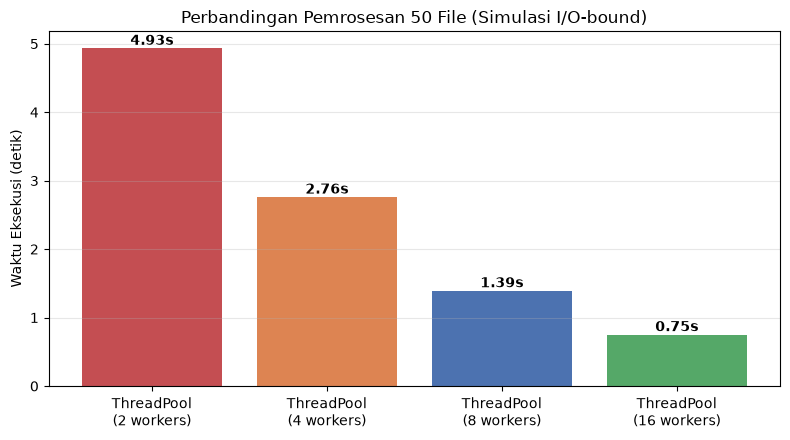


Catatan Analisis:
1. Menambah max_workers dari 2 ke 4 dan 8 mempercepat proses secara signifikan.
2. Tapi dari 8 ke 16 workers, efisiensinya mulai mengalami titik jenuh (diminishing returns)
   karena batasan core CPU, overhead context switching, dan GIL CPython.


In [7]:
# 3. Grafik
import matplotlib.pyplot as plt

metode = [f"ThreadPool\n({w} workers)" for w in WORKERS_LIST]
warna_bars = ["#C44E52", "#DD8452", "#4C72B0", "#55A868"]

plt.figure(figsize=(8, 4.5))
bars = plt.bar(metode, waktu_eksekusi, color=warna_bars)
plt.ylabel("Waktu Eksekusi (detik)")
plt.title(f"Perbandingan Pemrosesan {JUMLAH_FILE} File (Simulasi I/O-bound)")

# Menambahkan label nilai di atas setiap batang
for b, w in zip(bars, waktu_eksekusi):
    plt.text(b.get_x() + b.get_width() / 2, w + 0.05, f"{w:.2f}s", ha='center', fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nCatatan Analisis:")
print("1. Menambah max_workers dari 2 ke 4 dan 8 mempercepat proses secara signifikan.")
print("2. Tapi dari 8 ke 16 workers, efisiensinya mulai mengalami titik jenuh (diminishing returns)")
print("   karena batasan core CPU, overhead context switching, dan GIL CPython.")

In [ ]:
# 4.

# Threading Python membantu pada kasus I/O-bound, seperti bot web scraper
# yang mengunduh data dari ratusan tautan produk e-commerce secara bersamaan.
# Saat satu thread menunggu tanggapan server (network delay), GIL dilepas
# sehingga thread lain dapat langsung mengirim permintaan HTTP berikutnya.
# Hal ini membuat proses pengunduhan selesai jauh lebih cepat dibanding metode sekuensial.

# Threading Python tidak membantu pada kasus CPU-bound, seperti pemrosesan dan manipulasi
# matriks citra medis berukuran raksasa menggunakan algoritma matematis murni. Karena dibatasi
# oleh Global Interpreter Lock (GIL) CPython, hanya satu thread yang bisa mengeksekusi
# bytecode Python di satu core CPU pada satu waktu. Menambahkan thread justru memperlambat
# proses akibat beban context switching. Kasus seperti ini sebaiknya menggunakan
# multiprocessing agar dapat memanfaatkan banyak core CPU secara paralel.